# 02. Exploratory Data Analysis (EDA) & Visualizations

## Overview
This notebook conducts **Exploratory Data Analysis (EDA)** and generates high-impact visual plots for the Loan Approval Prediction project.
All plot figures are exported to `../reports/figures/` for the Supervised Learning visualization handoff package.


## 1. Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "Arial"

figures_dir = "../reports/figures"
os.makedirs(figures_dir, exist_ok=True)

data_path = "../data/processed/cleaned_loan_data.csv"
df = pd.read_csv(data_path)
print("Loaded dataset with shape:", df.shape)
df.head()

Loaded dataset with shape: (1000, 5)


,income,credit_score,loan_amount,employment_years,loan_status
0,141958,760,43525,16,1
1,35795,846,37556,4,1
2,20860,552,17595,11,1
3,123694,689,6969,10,1
4,148106,555,48753,14,0


## 2. Target Distribution Analysis (`loan_status`)

C:\Users\Kishore\AppData\Local\Temp\ipykernel_11556\2021987274.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='loan_status', palette=['#e63946', '#2a9d8f'])


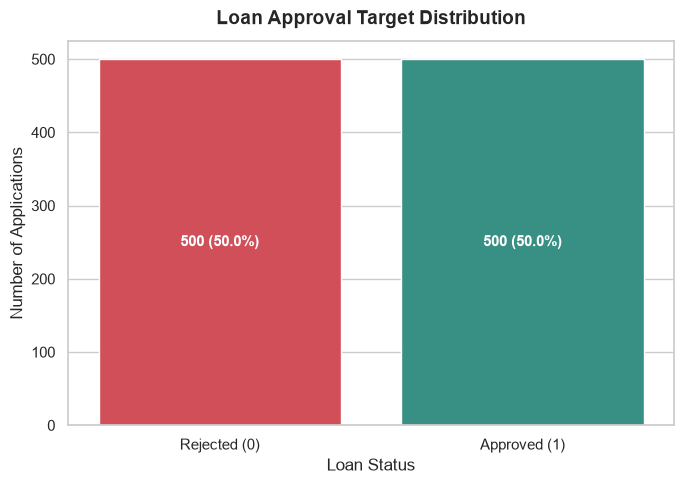

Saved target distribution plot to ../reports/figures\target_distribution.png


In [2]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='loan_status', palette=['#e63946', '#2a9d8f'])
plt.title("Loan Approval Target Distribution", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Loan Status", fontsize=12)
plt.ylabel("Number of Applications", fontsize=12)
plt.xticks([0, 1], ["Rejected (0)", "Approved (1)"])

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{int(height)} ({height/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
fig_path = os.path.join(figures_dir, "target_distribution.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved target distribution plot to {fig_path}")

## 3. Univariate Feature Distributions

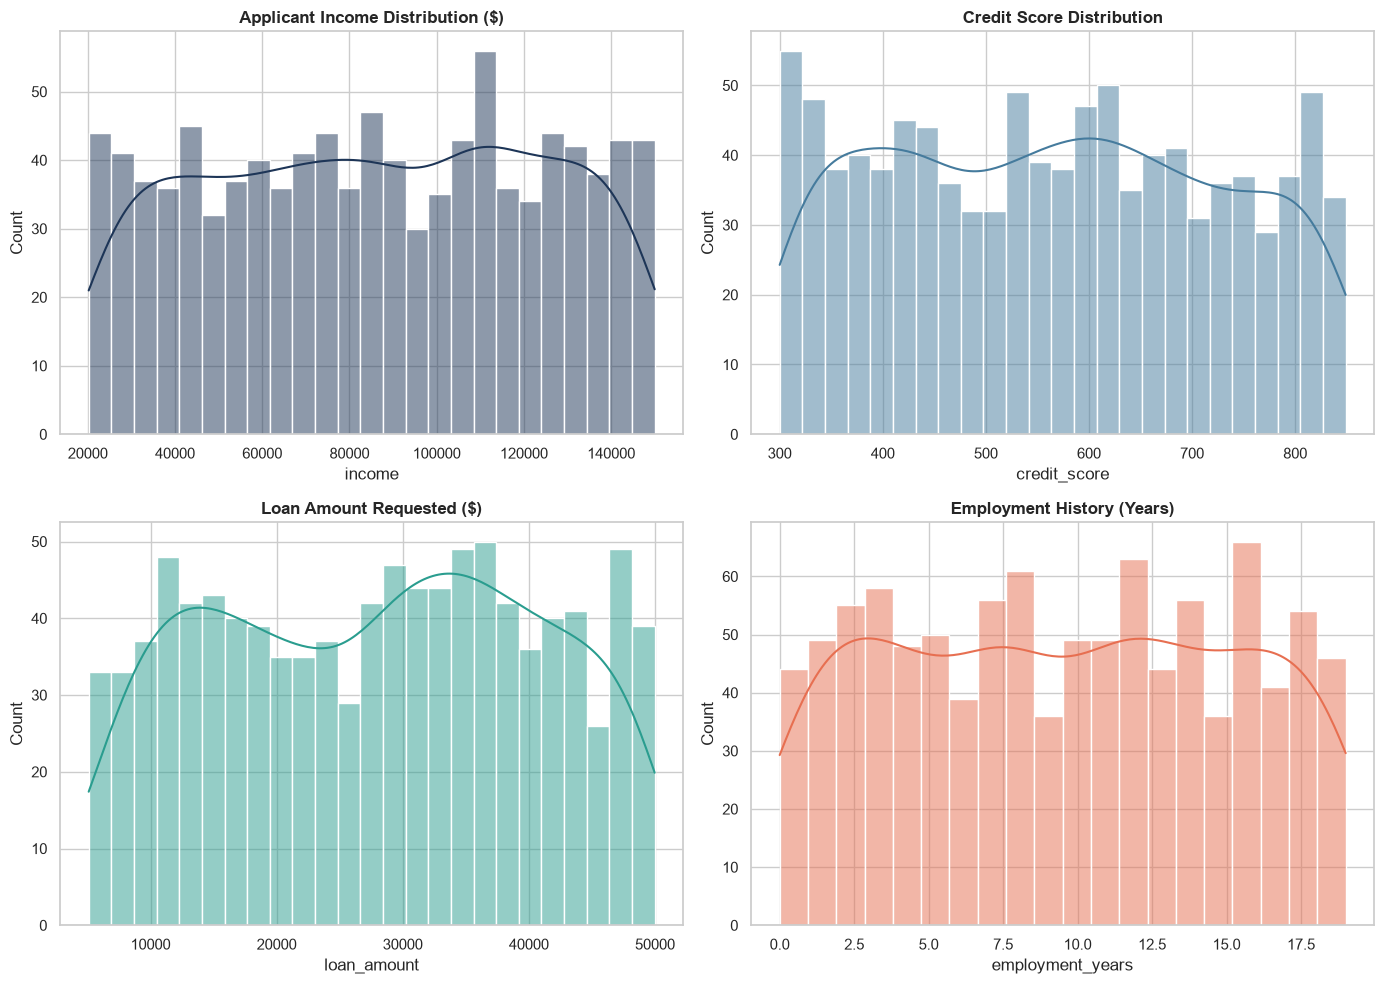

Saved feature distributions plot to ../reports/figures\feature_distributions.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Income
sns.histplot(df['income'], kde=True, ax=axes[0,0], color='#1d3557', bins=25)
axes[0,0].set_title("Applicant Income Distribution ($)", fontweight='bold')

# Credit Score
sns.histplot(df['credit_score'], kde=True, ax=axes[0,1], color='#457b9d', bins=25)
axes[0,1].set_title("Credit Score Distribution", fontweight='bold')

# Loan Amount
sns.histplot(df['loan_amount'], kde=True, ax=axes[1,0], color='#2a9d8f', bins=25)
axes[1,0].set_title("Loan Amount Requested ($)", fontweight='bold')

# Employment Years
sns.histplot(df['employment_years'], kde=True, ax=axes[1,1], color='#e76f51', bins=20)
axes[1,1].set_title("Employment History (Years)", fontweight='bold')

plt.tight_layout()
fig_path = os.path.join(figures_dir, "feature_distributions.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved feature distributions plot to {fig_path}")

## 4. Feature Spread & Outliers by Target Class

C:\Users\Kishore\AppData\Local\Temp\ipykernel_11556\1624689581.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y='income', ax=axes[0,0], palette=['#e63946', '#2a9d8f'])
C:\Users\Kishore\AppData\Local\Temp\ipykernel_11556\1624689581.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0,0].set_xticklabels(["Rejected", "Approved"])
C:\Users\Kishore\AppData\Local\Temp\ipykernel_11556\1624689581.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y='credit_score', ax=axes[0,1], palette=['#e63946', '#2a9d8f'])
C:\User

C:\Users\Kishore\AppData\Local\Temp\ipykernel_11556\1624689581.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1,1].set_xticklabels(["Rejected", "Approved"])


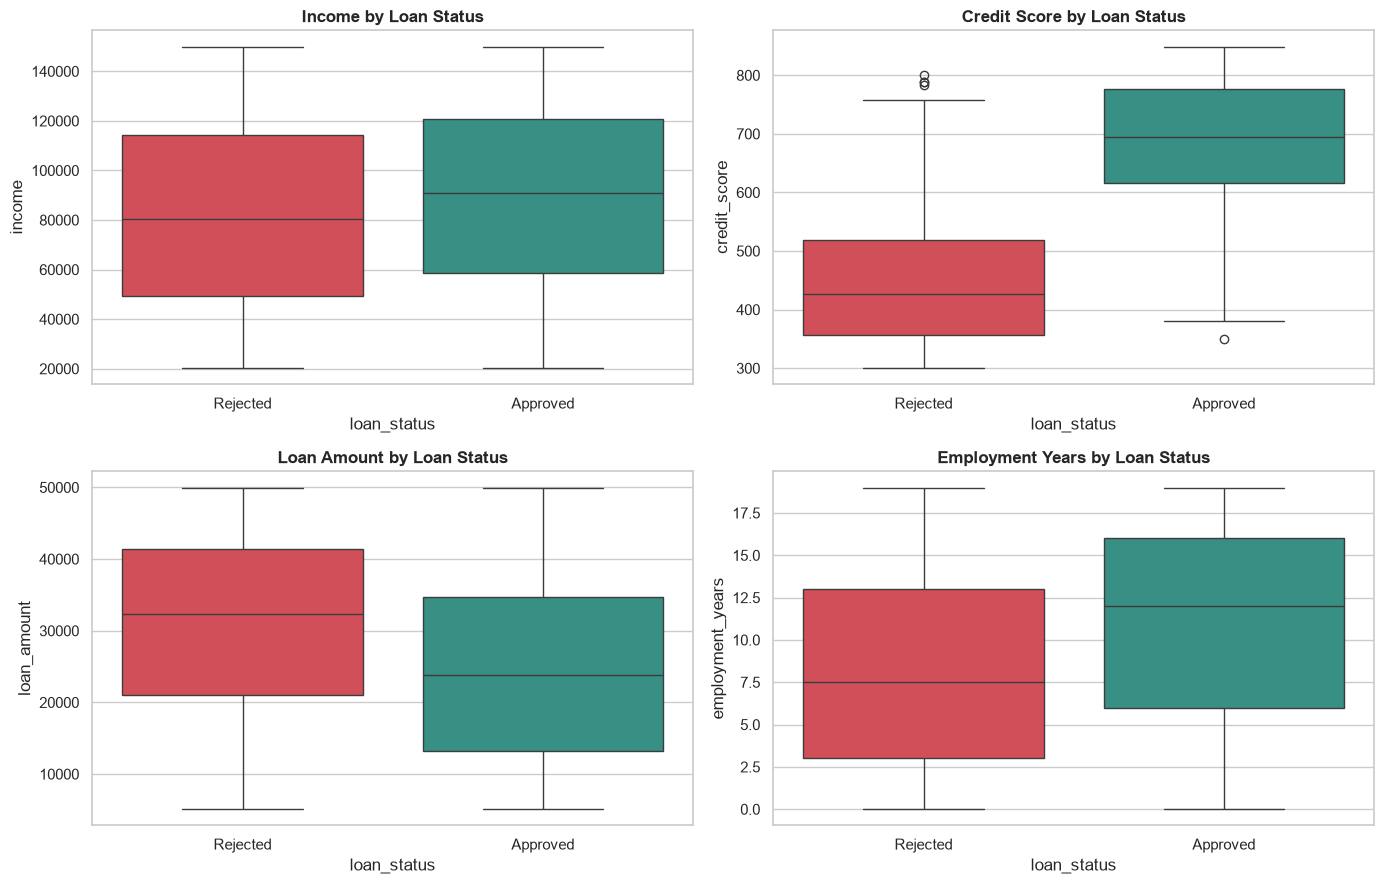

Saved boxplots plot to ../reports/figures\boxplot_outliers.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(data=df, x='loan_status', y='income', ax=axes[0,0], palette=['#e63946', '#2a9d8f'])
axes[0,0].set_title("Income by Loan Status", fontweight='bold')
axes[0,0].set_xticklabels(["Rejected", "Approved"])

sns.boxplot(data=df, x='loan_status', y='credit_score', ax=axes[0,1], palette=['#e63946', '#2a9d8f'])
axes[0,1].set_title("Credit Score by Loan Status", fontweight='bold')
axes[0,1].set_xticklabels(["Rejected", "Approved"])

sns.boxplot(data=df, x='loan_status', y='loan_amount', ax=axes[1,0], palette=['#e63946', '#2a9d8f'])
axes[1,0].set_title("Loan Amount by Loan Status", fontweight='bold')
axes[1,0].set_xticklabels(["Rejected", "Approved"])

sns.boxplot(data=df, x='loan_status', y='employment_years', ax=axes[1,1], palette=['#e63946', '#2a9d8f'])
axes[1,1].set_title("Employment Years by Loan Status", fontweight='bold')
axes[1,1].set_xticklabels(["Rejected", "Approved"])

plt.tight_layout()
fig_path = os.path.join(figures_dir, "boxplot_outliers.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved boxplots plot to {fig_path}")

## 5. Feature Correlation Heatmap

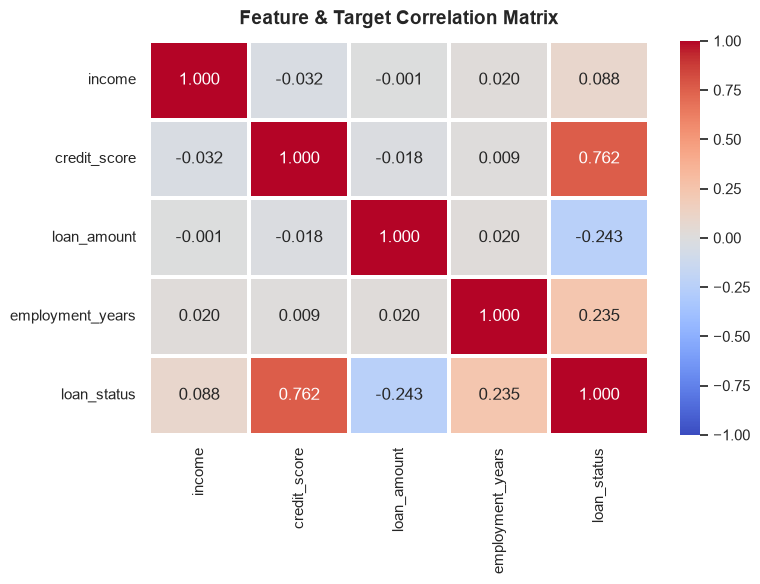

Saved correlation matrix plot to ../reports/figures\correlation_matrix.png


In [5]:
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', linewidths=1.5, vmin=-1, vmax=1)
plt.title("Feature & Target Correlation Matrix", fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()

fig_path = os.path.join(figures_dir, "correlation_matrix.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved correlation matrix plot to {fig_path}")

## 6. Income vs Loan Amount Scatter Analysis

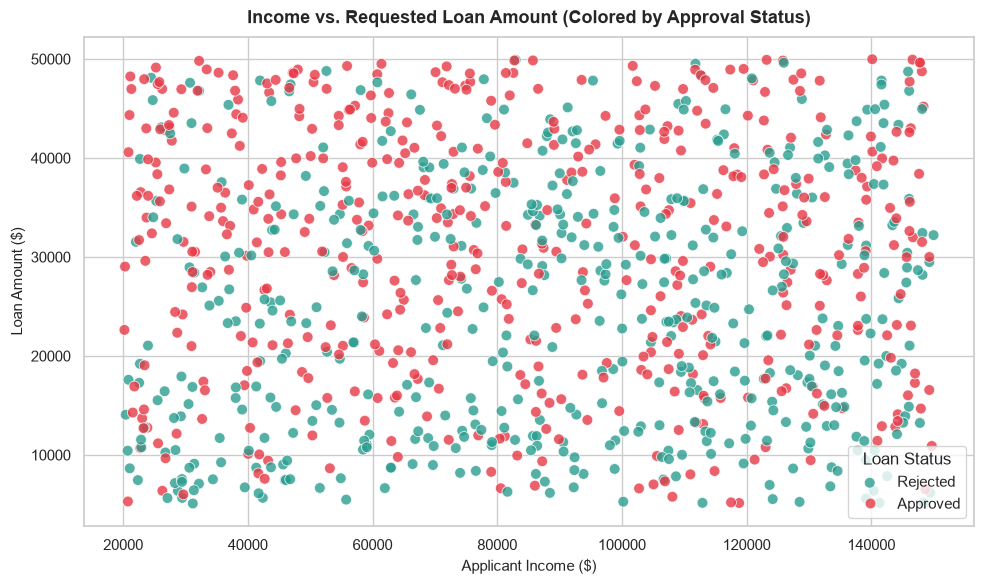

Saved scatter plot to ../reports/figures\income_vs_loan_scatter.png


In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='income',
    y='loan_amount',
    hue='loan_status',
    palette=['#e63946', '#2a9d8f'],
    alpha=0.8,
    s=60
)
plt.title("Income vs. Requested Loan Amount (Colored by Approval Status)", fontsize=13, fontweight='bold', pad=10)
plt.xlabel("Applicant Income ($)", fontsize=11)
plt.ylabel("Loan Amount ($)", fontsize=11)
plt.legend(title="Loan Status", labels=["Rejected", "Approved"])

plt.tight_layout()
fig_path = os.path.join(figures_dir, "income_vs_loan_scatter.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved scatter plot to {fig_path}")